In [ ]:
# -----------------------------------------------------------------------
# Original code copyright Nicolas Nemeth, Christoph Flamm 2025
# Licensed under Attribution-NonCommercial-ShareAlike 4.0 International
# -----------------------------------------------------------------------

In [2]:
import os
import sys
import subprocess
sys.path.append("/lib")

from matplotlib import pyplot as plt

from utils.chemutils import *
from utils.junction_tree import JunctionTree
from utils.junction_forest_manager import JunctionForestManager

from rl.metrics_interface import MetricSpec
from rl.config import PotentialRLConfig

import mod
from tqdm import tqdm
from utils.mod_rule import ModRule
import time
import json

from pretraingnn.loader import mol_to_graph_data_obj_simple

if not os.path.exists("./out"): 
    os.makedirs("./out")    

MOD_POST_CMD = "/mydata/mod-repo/libs/post_mod/bin/mod_post"
WILD_STAR = "*"
X_VAR = "X"

In [3]:
pyrene = "C1=CC2=C3C(=C1)C=CC4=CC=CC(=C43)C=C2"
phenalene = "C1C=CC2=CC=CC3=C2C1=CC=C3"
ingenol = "C[C@@H]1C[C@@H]2[C@@H](C2(C)C)[C@@H]3C=C([C@H]([C@]4([C@@]1(C3=O)C=C([C@@H]4O)C)O)O)CO"
moleculeWhereOneAtomWith1BondAnd2Rings = "CC(C1CCC1)(C2CCCCC2)"
aspirin = "CC(=O)Oc1ccccc1C(=O)O"
diflunisal = "C1=CC(=C(C=C1C2=C(C=C(C=C2)F)F)C(=O)O)O"
glucose = "C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O"
naphtalen_diisocyanate = "C1=CC2=C(C=CC=C2N=C=O)C(=C1)N=C=O"

In [4]:
# jtt = JunctionTree.from_smiles(
#     ingenol, 
#     kekulize=True,
#     compute_2D_smiles=True,
#     recompute_modGraph_dueto_extids=True,
#     use_potential_model=False,
#     border_depth_limit=None,
#     max_atom_cutoff=4,
#     for_eligible_edges_include_wildstars=False)
# jtt.visualize()

In [167]:
with open("utils/data/isocyanates.txt", 'r') as ifile:
    smiles_lines = ifile.readlines()

molecule_set = [ sl.strip() for sl in smiles_lines ]

In [168]:
metric_specs = [
    # MetricSpec("validity", 1.0, True),
    # MetricSpec("uniqueness", 1.0, True),
    # MetricSpec("novelty", 1.0, True),
    # MetricSpec("diversity", 1.0, True),
    # MetricSpec("chamfer_distance", 1.0, True)
    # MetricSpec("rule_score", 1.0, True)
    MetricSpec("molecule_quality", 1.0, True)
]

cfg = PotentialRLConfig(
    max_episodes=20,
    max_steps_per_episode=300,
)

jt_forest_mg = JunctionForestManager(molecule_set, 
                                     kekulize=True, 
                                     compute_2D_smiles=True,
                                     max_iter_space_exploration=50,
                                     use_potential_model=True,
                                     use_frequency_bias=False,
                                     border_depth_limit=None,
                                     max_atom_cutoff=(2, 7),
                                     max_rule_application_execute_strat=10,
                                     for_eligible_edges_include_wildstars=False,
                                )

trained_model = jt_forest_mg.train_reinforcement(
    feature_dim=1206,
    rl_config=cfg,
    metric_specs=metric_specs,
    molecule_set=molecule_set,
    reconstruct_dataset_alpha=0.05,
    max_heavy_atom_count=40,
    make_all_mols_terminal=True,
    verbose=True,
)

RL Training Rounds:   0%|          | 0/20 [00:00<?, ?it/s]

# unique graphs: 5
# unique rules: 23
# terminal smiles: 180
[RL] Episode 1
  Steps: 29 | Induced Rules: 29
  Reward: 0.2598 | Advantage: 0.0000 | Baseline: 0.2598
  DG iterations: 17
  Loss: 0.7071 | Entropy Coef: 0.02000
  Raw Metrics:
    molecule_quality: 0.2598
  Contributions (weighted):
    molecule_quality: 0.2598


RL Training Rounds:   5%|▌         | 1/20 [00:03<01:06,  3.50s/it]

# unique graphs: 6
# unique rules: 24
# terminal smiles: 254


RL Training Rounds:  10%|█         | 2/20 [00:08<01:15,  4.18s/it]

...

RL Training Rounds:  90%|█████████ | 18/20 [01:11<00:07,  3.88s/it]

# unique graphs: 5
# unique rules: 24
# terminal smiles: 81


RL Training Rounds:  95%|█████████▌| 19/20 [01:15<00:03,  3.80s/it]

# unique graphs: 5
# unique rules: 17
# terminal smiles: 75
[RL] Episode 20
  Steps: 21 | Induced Rules: 21
  Reward: 0.2415 | Advantage: 0.0029 | Baseline: 0.2386
  DG iterations: 8
  Loss: -0.0433 | Entropy Coef: 0.02000
  Raw Metrics:
    molecule_quality: 0.2415
  Contributions (weighted):
    molecule_quality: 0.2415


RL Training Rounds: 100%|██████████| 20/20 [01:18<00:00,  3.91s/it]


In [158]:
rules = jt_forest_mg.best_rules
g_smiles = [ g.smiles for g in jt_forest_mg.best_initial_graphs ]

from utils.chemutils import reconstruct_dataset_from_rules

max_heavy_atom_count: int = int(max([ Chem.MolFromSmiles(smi).GetNumHeavyAtoms() for smi in molecule_set ]) * 0.9)
print(max_heavy_atom_count)
leaf_node_smiles, _ = reconstruct_dataset_from_rules(
    smiles=g_smiles,
    rules=rules,
    create_summary=False,
    apply_all_targets=False,
    max_iter_space_exploration=150,
    max_rule_application_execute_strat=10,
    alpha=None,
    max_heavy_atom_count=max_heavy_atom_count,
    make_all_mols_terminal=True,
    original_smiles=molecule_set,
    rule_reapplication_decay=0.15,
    enable_beam_search=True,
    pruning_threshold=0.2,
    # verbose=False
)

36


167


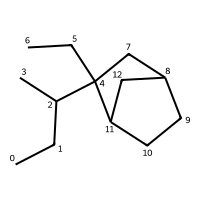

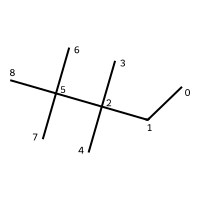

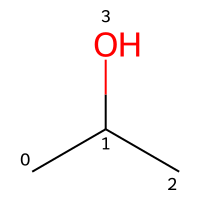

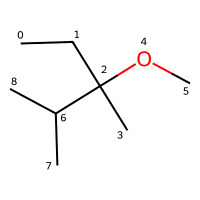

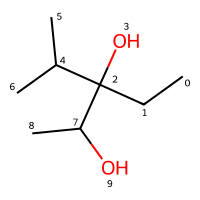

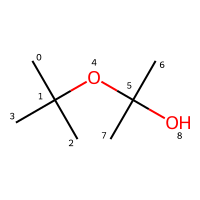

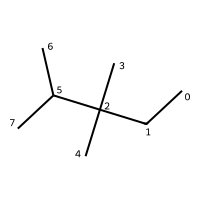

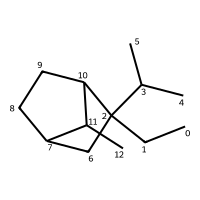

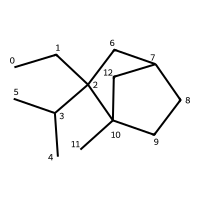

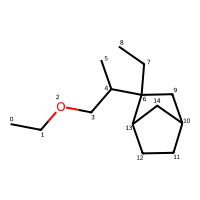

[None, None, None, None, None, None, None, None, None, None]

In [166]:
permutidxs = np.random.permutation(len(leaf_node_smiles))[:10]
print(len(leaf_node_smiles))

[ display_smiles(smi, size=(200,200)) for smi in np.array(sorted(leaf_node_smiles, key=lambda x: -len(x)))[permutidxs] ]

----

In [ ]:
#

----
## Example

In [ ]:
### grammar.py
AcP = mod.smiles("OP(O)(=O)OC(=O)C", "AcP") # Acetyl-Phosphate
G3P = mod.smiles("C(C(C=O)O)OP(=O)(O)O", "G3P") # Glyceraldehyde 3-phosphate
E4P = mod.smiles("OP(O)(=O)OCC(O)C(O)C=O", "E4P") # Erythrose-4-phosphate
R5P = mod.smiles("OP(O)(=O)OCC(O)C(O)C(O)C=O", "R5P") # Ribose 5-phosphate
Ru5P = mod.smiles("OCC(=O)C(O)C(O)COP(=O)(O)O", "Ru5P") # Ribulose-5-Phosphate
ribuloseP = Ru5P # TODO: remove at some point
F6P = mod.smiles("OCC(=O)C(O)C(O)C(O)COP(=O)(O)O", "F6P") # Fructose-6-Phosphate
fructoseP = F6P # TODO: remove at some point
S7P = mod.smiles("O=P(O)(OCC(O)C(O)C(O)C(O)C(=O)CO)O", "S7P") # Sedoheptulose 7-phosphate
water = mod.smiles("O", "Water")
Pi = mod.smiles("O=P(O)(O)O", "Pi")
phosphate = Pi # TODO: remove at some point

aldoKetoF = mod.ruleGML("utils/data/aldo_keto_backward.gml")
aldoKetoB = mod.ruleGML("utils/data/aldo_keto_forward.gml")
transKeto = mod.ruleGML("utils/data/transketolase.gml")
Tkt = transKeto
transAldo = mod.ruleGML("utils/data/transaldolase.gml")
Tal = transAldo
aldolase = mod.ruleGML("utils/data/aldolase.gml")
phosphohydro = mod.ruleGML("utils/data/phosphohydrolase.gml")

aldolaseReal = mod.leftPredicate[lambda d: any(a.vLabelCount("C") > 2 for a in d.left)](aldolase)

rulesGeneric = [aldoKetoF, aldoKetoB, transKeto, transAldo, aldolase, phosphohydro]
rulesReal = [aldoKetoF, aldoKetoB, transKeto, transAldo, aldolaseReal, phosphohydro]

In [ ]:
aceton: mod.Graph = mod.smiles("CC(=O)C", "Aceton")

# define rewrite rules via graphDFS
r0: mod.Rule = mod.Rule.fromDFS("[C]1>>[Si]1")
r0.name = "replace C with Si"
r1: mod.Rule = mod.Rule.fromDFS("[O]1>>[S]1")
r1.name = "replace O with S"

inputRules = [r0, r1]

In [ ]:
p = mod.DGPrinter()
p.graphvizPrefix = 'layout = "dot";'

ss = [ # building blocks strategy string
    ['r1', 'r0', 'r0', 'r0'], # addSubset(aceton) >> r1 >> r0 >> r0 >> r0
    ['r0', 'r1', 'r0', 'r0'], # addSubset(aceton) >> r0 >> r1 >> r0 >> r0
    ['r0', 'r0', 'r1', 'r0'], # addSubset(aceton) >> r0 >> r0 >> r1 >> r0
    ['r0', 'r0', 'r0', 'r1'], # addSubset(aceton) >> r0 >> r0 >> r0 >> r1
    ['[r0, r1]', 'r0'], # addSubset(aceton) >> [r0, r1] >> r0
    ['[r0, r1]', 'r1'], # addSubset(aceton) >> [r0, r1] >> r1
    ['[r0, r1]', '[r0, r1]'], # addSubset(aceton) >> [r0, r1] >> [r0, r1]
    ['mod.repeat[2]([r0, r1])'], # addSubset(aceton) >> repeat[2]([r0, r1])
    ['mod.repeat(mod.revive(r0))','r1'], # addSubset(aceton) >> repeat(revive(r0)) >> r1
    ['mod.repeat(mod.revive([r0, r1]))'] # addSubset(aceton) >> repeat(revive([r0, r1]))
]

for s in ss:
    s = " >> ".join(s)
    mod.post.summarySection(f'Build space from strategy {s}')
    print(f'=== Build space from strategy {s} ===')
    # build strategy from python string
    strat = eval(' >> '.join(['mod.addSubset(aceton)'] + [s]))
    dg: mod.DG = mod.DG(graphDatabase=mod.inputGraphs) # all loaded graphs are added to a list 'inputGraphs'
    dg.build().execute(strat)
    dg.print(p)

mod.post.summarySection("Build space via apply framework")
print("=== Build space via apply framework ===")
dg = mod.DG(graphDatabase=mod.inputGraphs)
currMols = set([aceton])

cnt = 0
with dg.build() as b:
    b: mod.DG.Builder = b
    while(len(currMols)> 0):
        m = currMols.pop()
        res: List[mod.DG.HyperEdge] = b.apply([m], r0)
        res += b.apply([m], r1)
        cnt += 1
        newMolsP: Set[mod.Graph] = set([x.graph for d in res for x in d.targets])
        print(f"Round {cnt}: Result subset has {len(newMolsP)} graphs")
        print( " ", [x.smiles for x in newMolsP])
        currMols |= newMolsP

dg.print(p)
mod.post.enableCompileSummary()
mod.post.enableInvokeMake()
mod.post.flushCommands()

### Generate summary.pdf
%cd /myData/MasterThesis/
subprocess.run([MOD_POST_CMD])

---

🧩 Tips on Strategy Language
You can build strategies using a Python DSL with:

- addUniverse(graphs) – add graphs to explore.
- repeat[[n]](strategy) – repeat strategy up to n times.
- makeRule(rule) – apply a rule.
- filterSubset(predicate) – filter results.
- revive(strategy) – restart strategy on new graphs.

---

✅ When to Use What
| Method          | Use Case Example                                                      |
| --------------- | --------------------------------------------------------------------- |
| `addDerivation` | You want to manually record that A transforms to B with rule R.       |
| `addHyperEdge`  | You want to copy transformations from another derivation graph.       |
| `apply`         | You want to see what happens when you apply a rule to certain graphs. |
| `execute`       | You want to automate applying rules to generate new derivations.      |

---

----

**Test whether rule is embedded in rule1 or a sub-pattern of rule1**
> rule1.monomorphism(rule) 

**Test if transformation obtained by rule is structurally identical to transformation obtained by rule1**
**i.e. rule1 = rule up to renaming of nodes or reordering**
> rule1.isomorphism(rule) 

**Check if two reactions do the same transofrmation, possibly under different node/edge names or orderings**
**-> checks structural equivalende of reactants and products separately**
> rule1.isomorphicLeftRight(rule)

---

**LabelType**

1. LabelType.String
> * labels are treated as plain strings
> * matching uses string equality
2. Labeltype.Term (when labels also encode structure like atom charge etc.)
> * labels are treated as first-order logic terms, e.g. `atom(C)` or `bond(single)`
> * matching involves parsing the strings into terms with structure

**LabelRelation**

1. LabelRelation.Isomorphism
> * labels must be isomorphic under renaming
> * terms match if they are structurally the same, ignoring variable names
> * use when label variables are not semantically significant
2. LabelRelation.Specialisation
> * right-hand side label can be more specific than the left
> * there must be a substitution from variables in the left to values in the right
> * e.g. a rule with `atom(X)` could match a graph node labeled `atom(C)`
> * `atom(X)` specialises to `atom(C)` (substitute `X = C`)
3. LabelRelation.Unification
> * terms unify if there is a most general unifier
> * more general than isomorphism and specialisation
> * algorithm finds a substitution that makes both terms euqal
> * useful for more flexible pattern matching with partial information

---

| Rule Label | Graph Label | Relation          | Match? (with `Term`) |
| ---------- | ----------- | ----------------- | -------------------- |
| `atom(X)`  | `atom(C)`   | Specialisation    | ✅ Yes                |
| `atom(C)`  | `atom(X)`   | Specialisation    | ❌ No                 |
| `atom(X)`  | `atom(Y)`   | Isomorphism (X↔Y) | ✅ Yes                |
| `atom(X)`  | `atom(C)`   | Unification       | ✅ Yes                |
| `atom(C)`  | `atom(C)`   | All relations     | ✅ Yes                |

---

## Retrosynthesis, Fragmentation, and Bond Retention

🔍 In retrosynthesis and fragmentation processes, it is typical and expected to:

*   Retain the bond information with the fragment that remains, even if the bond no longer connects to another atom.
*   Represent "open valences" or "dangling bonds" on the retained fragment.

This approach reflects the concept of chemically reactive or incomplete sites, often referred to as "attachment points," "leaving groups," or "reaction sites."

🧪 **Rationale: Bond Retention on the Retained (Left) Part**

*   **Chemical Reality:** Molecular splitting involves breaking a bond, not just removing an atom. The retained fragment then possesses a reactive site (implicit hydrogen, lone pair, radical, etc.). The bond context is crucial for understanding subsequent reactions at this site.

*   **Practical Modeling:** Retaining the broken bond within the retained graph facilitates:

    *   Generating meaningful rewrite rules (DPO-style).
    *   Applying context-sensitive transformations.
    *   Maintaining syntactic and semantic anchoring to indicate where the splits occurred.

*   **Consistency with Retrosynthetic Thinking:** In cheminformatics tools such as RDKit, MØD, and AiZynthFinder, the concept of "fragment with attachment point" is prevalent. For example:

    `[CH3:1]-[C:2]-[OH:3] → [CH3:1]-[C:2] (attachment point at C2)`

    This aligns with modeling the remaining fragment with awareness of what was attached and removed.

📦 **Visualization**

Consider the molecule: `CH3–CH2–OH`

*   **Fragmentation:** Splitting off `-OH`.

*   **Left (Retained Fragment):** `CH3–CH2–(*)`  (Retains the broken bond site)

*   **Right (Removed Fragment):** `OH`

Where `(*)` could be represented as:

*   A wildcard atom.
*   A labeled attachment point.
*   An open valence.
*   A dangling bond edge in the graph.

This approach is widely used in scaffold extraction, retrosynthesis, and generative molecular design.

In [ ]:
# ---------------------------------------------------------
# Feature Analysis with UMAP
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
try:
    import umap
except ImportError:
    import umap.umap_ as umap

# 1. Gather all edge features from the forest
all_feats = []
all_labels = []  # Optional: if we had labels (e.g. is_ring, size, etc.)

for smi, jt in jt_forest_mg.junction_trees.items():
    if jt.edge_gnn_feats is not None and len(jt.edge_gnn_feats) > 0:
        all_feats.append(jt.edge_gnn_feats)

if all_feats:
    X = np.concatenate(all_feats, axis=0)
    print(f"Feature matrix shape: {X.shape}")

    # 2. Run UMAP
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean')
    embedding = reducer.fit_transform(X)

    # 3. Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], s=5, alpha=0.6, c='blue')
    plt.title("UMAP projection of Edge Features (GNN + Structural)")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.show()
else:
    print("No edge features found in the junction forest.")
